In [1]:
from pathlib import Path
import pickle
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Polygon
from hydrax.utils.files import get_data_path
from scipy.ndimage import uniform_filter1d  # Or use np.convolve



def rotmat(yaw: float) -> np.ndarray:
    c, s = math.cos(yaw), math.sin(yaw)
    return np.array([[c, -s],
                     [s,  c]])
    
def rectangle_corners(center_xy, width, height, yaw):
    cx, cy = center_xy
    R = rotmat(yaw)
    hw, hh = width / 2.0, height / 2.0
    local = np.array([
        [-hw, -hh],
        [ hw, -hh],
        [ hw,  hh],
        [-hw,  hh],
    ])
    world = (local @ R.T) + np.array([cx, cy])
    return world

def t_shape_polys(x, y, yaw, stem_w, stem_h, head_w, head_h):
    stem_center_local = np.array([0.0, -head_h / 2.0])
    head_center_local = np.array([0.0,  stem_h / 2.0])

    stem_center_world = (stem_center_local @ rotmat(yaw).T) + np.array([x, y])
    head_center_world = (head_center_local @ rotmat(yaw).T) + np.array([x, y])

    stem_poly = rectangle_corners(stem_center_world, stem_w, stem_h, yaw)
    head_poly = rectangle_corners(head_center_world, head_w, head_h, yaw)
    return stem_poly, head_poly

def plot_action_space(ax, xmin, xmax, ymin, ymax, show_grid=False, grid_dx=0.25):
    ax.add_patch(Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, fill=False, linewidth=1.5))
    if show_grid and grid_dx > 0:
        xv = np.arange(math.ceil(xmin / grid_dx) * grid_dx, xmax + 1e-9, grid_dx)
        yv = np.arange(math.ceil(ymin / grid_dx) * grid_dx, ymax + 1e-9, grid_dx)
        for xx in xv:
            ax.plot([xx, xx], [ymin, ymax], linewidth=0.4)
        for yy in yv:
            ax.plot([xmin, xmax], [yy, yy], linewidth=0.4)

def draw_t(ax, x, y, yaw_deg, stem_w, stem_h, head_w, head_h,
           face_alpha=0.4, edge_width=0.0, facecolor=None, edgecolor=None, label=None):
    yaw = yaw_deg#math.radians(yaw_deg)
    stem_poly, head_poly = t_shape_polys(x, y, yaw, stem_w, stem_h, head_w, head_h)
    poly_kwargs = dict(closed=True, alpha=face_alpha)
    if facecolor is not None:
        poly_kwargs["facecolor"] = facecolor
    if edgecolor is not None:
        poly_kwargs["edgecolor"] = edgecolor

    stem_patch = Polygon(stem_poly, **poly_kwargs, linewidth=edge_width)
    head_patch = Polygon(head_poly, **poly_kwargs, linewidth=edge_width)
    ax.add_patch(stem_patch)
    ax.add_patch(head_patch)
    if label:
        ax.text(x, y, label, ha="center", va="center", fontsize=10)
    return np.vstack([stem_poly, head_poly])

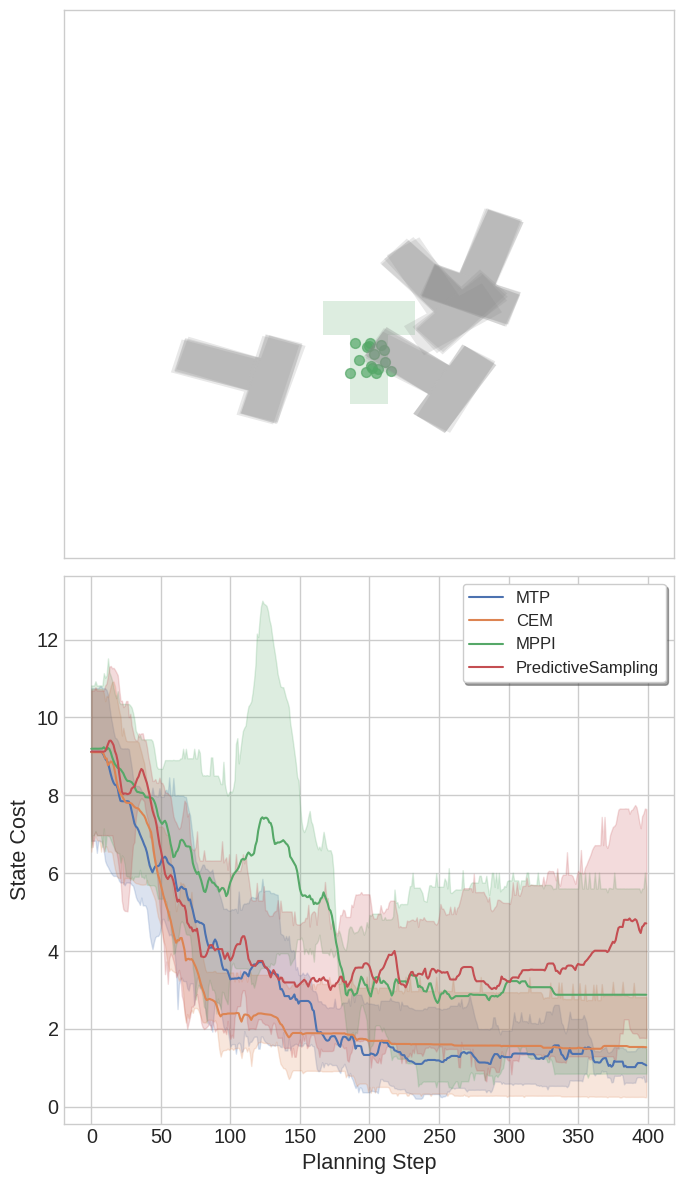

In [29]:
import seaborn as sns
import pandas as pd
sns.set(font_scale=1.3, rc={'font.size':12, 'font.family':'serif'})
seeds = [0, 1, 2 , 3]



def quat_to_yaw_manual(qx, qy, qz, qw):
    # Normalize
    norm = np.sqrt(qx**2 + qy**2 + qz**2 + qw**2)
    qw /= norm; qx /= norm; qy /= norm; qz /= norm
    
    sin_yaw_2 = 2 * (qw * qz + qx * qy)
    cos_yaw_2 = 1 - 2 * (qy**2 + qz**2)
    yaw = np.arctan2(sin_yaw_2, cos_yaw_2)
    return np.rad2deg(yaw)

# Collect all data into long-form DataFrame
df_list = []
init_T = []

for algo in ["MTP", "CEM", "MPPI", "PredictiveSampling"]:
    for seed in seeds:
        
        path = get_data_path() / "sim-real-3dof" / f"fr3_pusht_{algo}_seed{seed}.pkl"
        with open(path, "rb") as f:
            data = pickle.load(f)
            
        quat = np.array(data[0]['object_quat'])
        # quat to yaw
        jaw = quat_to_yaw_manual(quat[3], quat[0], quat[1], quat[2])
        init_T.append(np.concatenate((np.array(data[5]['object_pos'][:2]), np.array([jaw]))))
        timestep = np.arange(min(400, len(data)))
        df_list.append(pd.DataFrame({
            'timestep': timestep,
            'terminal_error': [d["terminal_error"] for d in data[:400]],
            'algo': algo,
            'seed': seed
        }))

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 1, figsize=(7, 12))
df = pd.concat(df_list)
init_Ts = np.array(init_T)


init_ee = np.ones((init_Ts.shape[0], 2)) * np.array([0.0, 0.5])
init_ee += np.random.uniform(-0.03, 0.03, size=init_ee.shape)
# plot
axes[0].scatter(init_ee[:, 0], init_ee[:, 1], s=50, c='C2', alpha=0.7, label='Initial end-effector')
draw_t(axes[0], 0.0, 0.5, 0.0, stem_w=0.05, stem_h=0.1, head_w=0.12, head_h=0.05,
           face_alpha=0.2, facecolor='C2')

# draw Ts
for i in range(init_Ts.shape[0]):
    x, y, yaw = init_Ts[i]
    yaw -= np.pi
    draw_t(axes[0], -y, x, yaw, stem_w=0.05, stem_h=0.1, head_w=0.12, head_h=0.05,
           face_alpha=0.2, facecolor='C7')

axes[0].set_xlim([-0.4, 0.4])
axes[0].set_ylim([0.2, 1.0])
# remove ticks
axes[0].set_xticks([])
axes[0].set_yticks([])

sns.lineplot(data=df, x='timestep', y='terminal_error', hue='algo', ax=axes[1])
axes[1].set_xlabel("Planning Step")
axes[1].set_ylabel("State Cost")
axes[1].legend(
    loc='upper right',           # Position: 'upper right', 'lower center', etc.
    frameon=True,                # Box around legend
    fancybox=True,               # Rounded box
    shadow=True,                 # Drop shadow
    ncol=1,                      # Columns (1=vertical)
    fontsize=12                  # Text size
)
plt.tight_layout()
plt.show()
